In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [136]:
df = pd.read_csv("data/2019.csv")
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [138]:
print(f"columns: {df.shape[1]}\nrows: {df.shape[0]}")

columns: 9
rows: 156


In [139]:
df.describe().round()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.0,156.0,156.0,156.0,156.0,156.0,156.0,156.0
mean,78.0,5.0,1.0,1.0,1.0,0.0,0.0,0.0
std,45.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,40.0,5.0,1.0,1.0,1.0,0.0,0.0,0.0
50%,78.0,5.0,1.0,1.0,1.0,0.0,0.0,0.0
75%,117.0,6.0,1.0,1.0,1.0,1.0,0.0,0.0
max,156.0,8.0,2.0,2.0,1.0,1.0,1.0,0.0


In [140]:
for col in df:
    per = df[col].isnull().sum() / df.shape[0] * 100
    print(f'{col}:     {per}')

Overall rank:     0.0
Country or region:     0.0
Score:     0.0
GDP per capita:     0.0
Social support:     0.0
Healthy life expectancy:     0.0
Freedom to make life choices:     0.0
Generosity:     0.0
Perceptions of corruption:     0.0


In [141]:
df.columns = df.columns.str.lower()

In [142]:
top_10 = df.sort_values("score", ascending = False).head(10)
top_10

,overall rank,country or region,score,gdp per capita,social support,healthy life expectancy,freedom to make life choices,generosity,perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


In [143]:
bottom_10 = df.sort_values("score", ascending = True).head(10)
bottom_10

,overall rank,country or region,score,gdp per capita,social support,healthy life expectancy,freedom to make life choices,generosity,perceptions of corruption
155,156,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
150,151,Yemen,3.380,0.287,1.163,0.463,0.143,0.108,0.077
149,150,Malawi,3.410,0.191,0.560,0.495,0.443,0.218,0.089
148,149,Syria,3.462,0.619,0.378,0.440,0.013,0.331,0.141
147,148,Botswana,3.488,1.041,1.145,0.538,0.455,0.025,0.100
146,147,Haiti,3.597,0.323,0.688,0.449,0.026,0.419,0.110


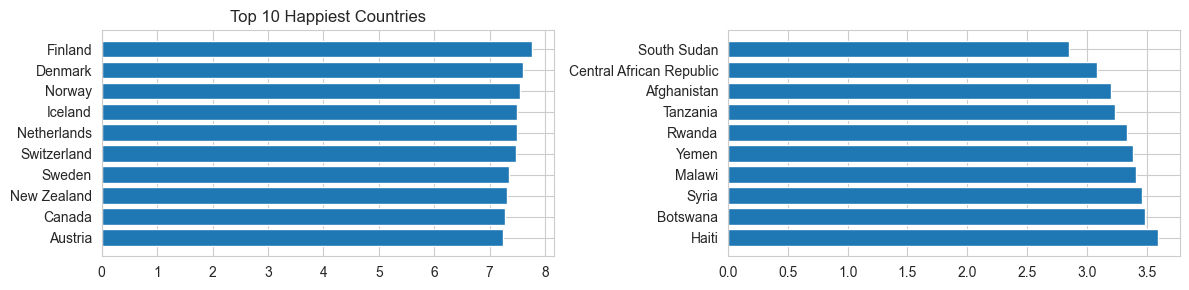

In [144]:
plt.figure(figsize=(12,3))
plt.subplot(121)
plt.barh(top_10["country or region"], top_10["score"])
plt.title("Top 10 Happiest Countries")
plt.gca().invert_yaxis()

plt.subplot(122)
plt.barh(bottom_10["country or region"], bottom_10["score"])
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [145]:
df["country or region"].unique()

array(['Finland', 'Denmark', 'Norway', 'Iceland', 'Netherlands',
       'Switzerland', 'Sweden', 'New Zealand', 'Canada', 'Austria',
       'Australia', 'Costa Rica', 'Israel', 'Luxembourg',
       'United Kingdom', 'Ireland', 'Germany', 'Belgium', 'United States',
       'Czech Republic', 'United Arab Emirates', 'Malta', 'Mexico',
       'France', 'Taiwan', 'Chile', 'Guatemala', 'Saudi Arabia', 'Qatar',
       'Spain', 'Panama', 'Brazil', 'Uruguay', 'Singapore', 'El Salvador',
       'Italy', 'Bahrain', 'Slovakia', 'Trinidad & Tobago', 'Poland',
       'Uzbekistan', 'Lithuania', 'Colombia', 'Slovenia', 'Nicaragua',
       'Kosovo', 'Argentina', 'Romania', 'Cyprus', 'Ecuador', 'Kuwait',
       'Thailand', 'Latvia', 'South Korea', 'Estonia', 'Jamaica',
       'Mauritius', 'Japan', 'Honduras', 'Kazakhstan', 'Bolivia',
       'Hungary', 'Paraguay', 'Northern Cyprus', 'Peru', 'Portugal',
       'Pakistan', 'Russia', 'Philippines', 'Serbia', 'Moldova', 'Libya',
       'Montenegro', 'Tajikis

In [146]:
df[df["country or region"] == "Iran"]

,overall rank,country or region,score,gdp per capita,social support,healthy life expectancy,freedom to make life choices,generosity,perceptions of corruption
116,117,Iran,4.548,1.1,0.842,0.785,0.305,0.27,0.125


In [147]:
l = LabelEncoder()
df["country or region"] = l.fit_transform(df["country or region"])

In [148]:
l.inverse_transform([43])

array(['Finland'], dtype=object)

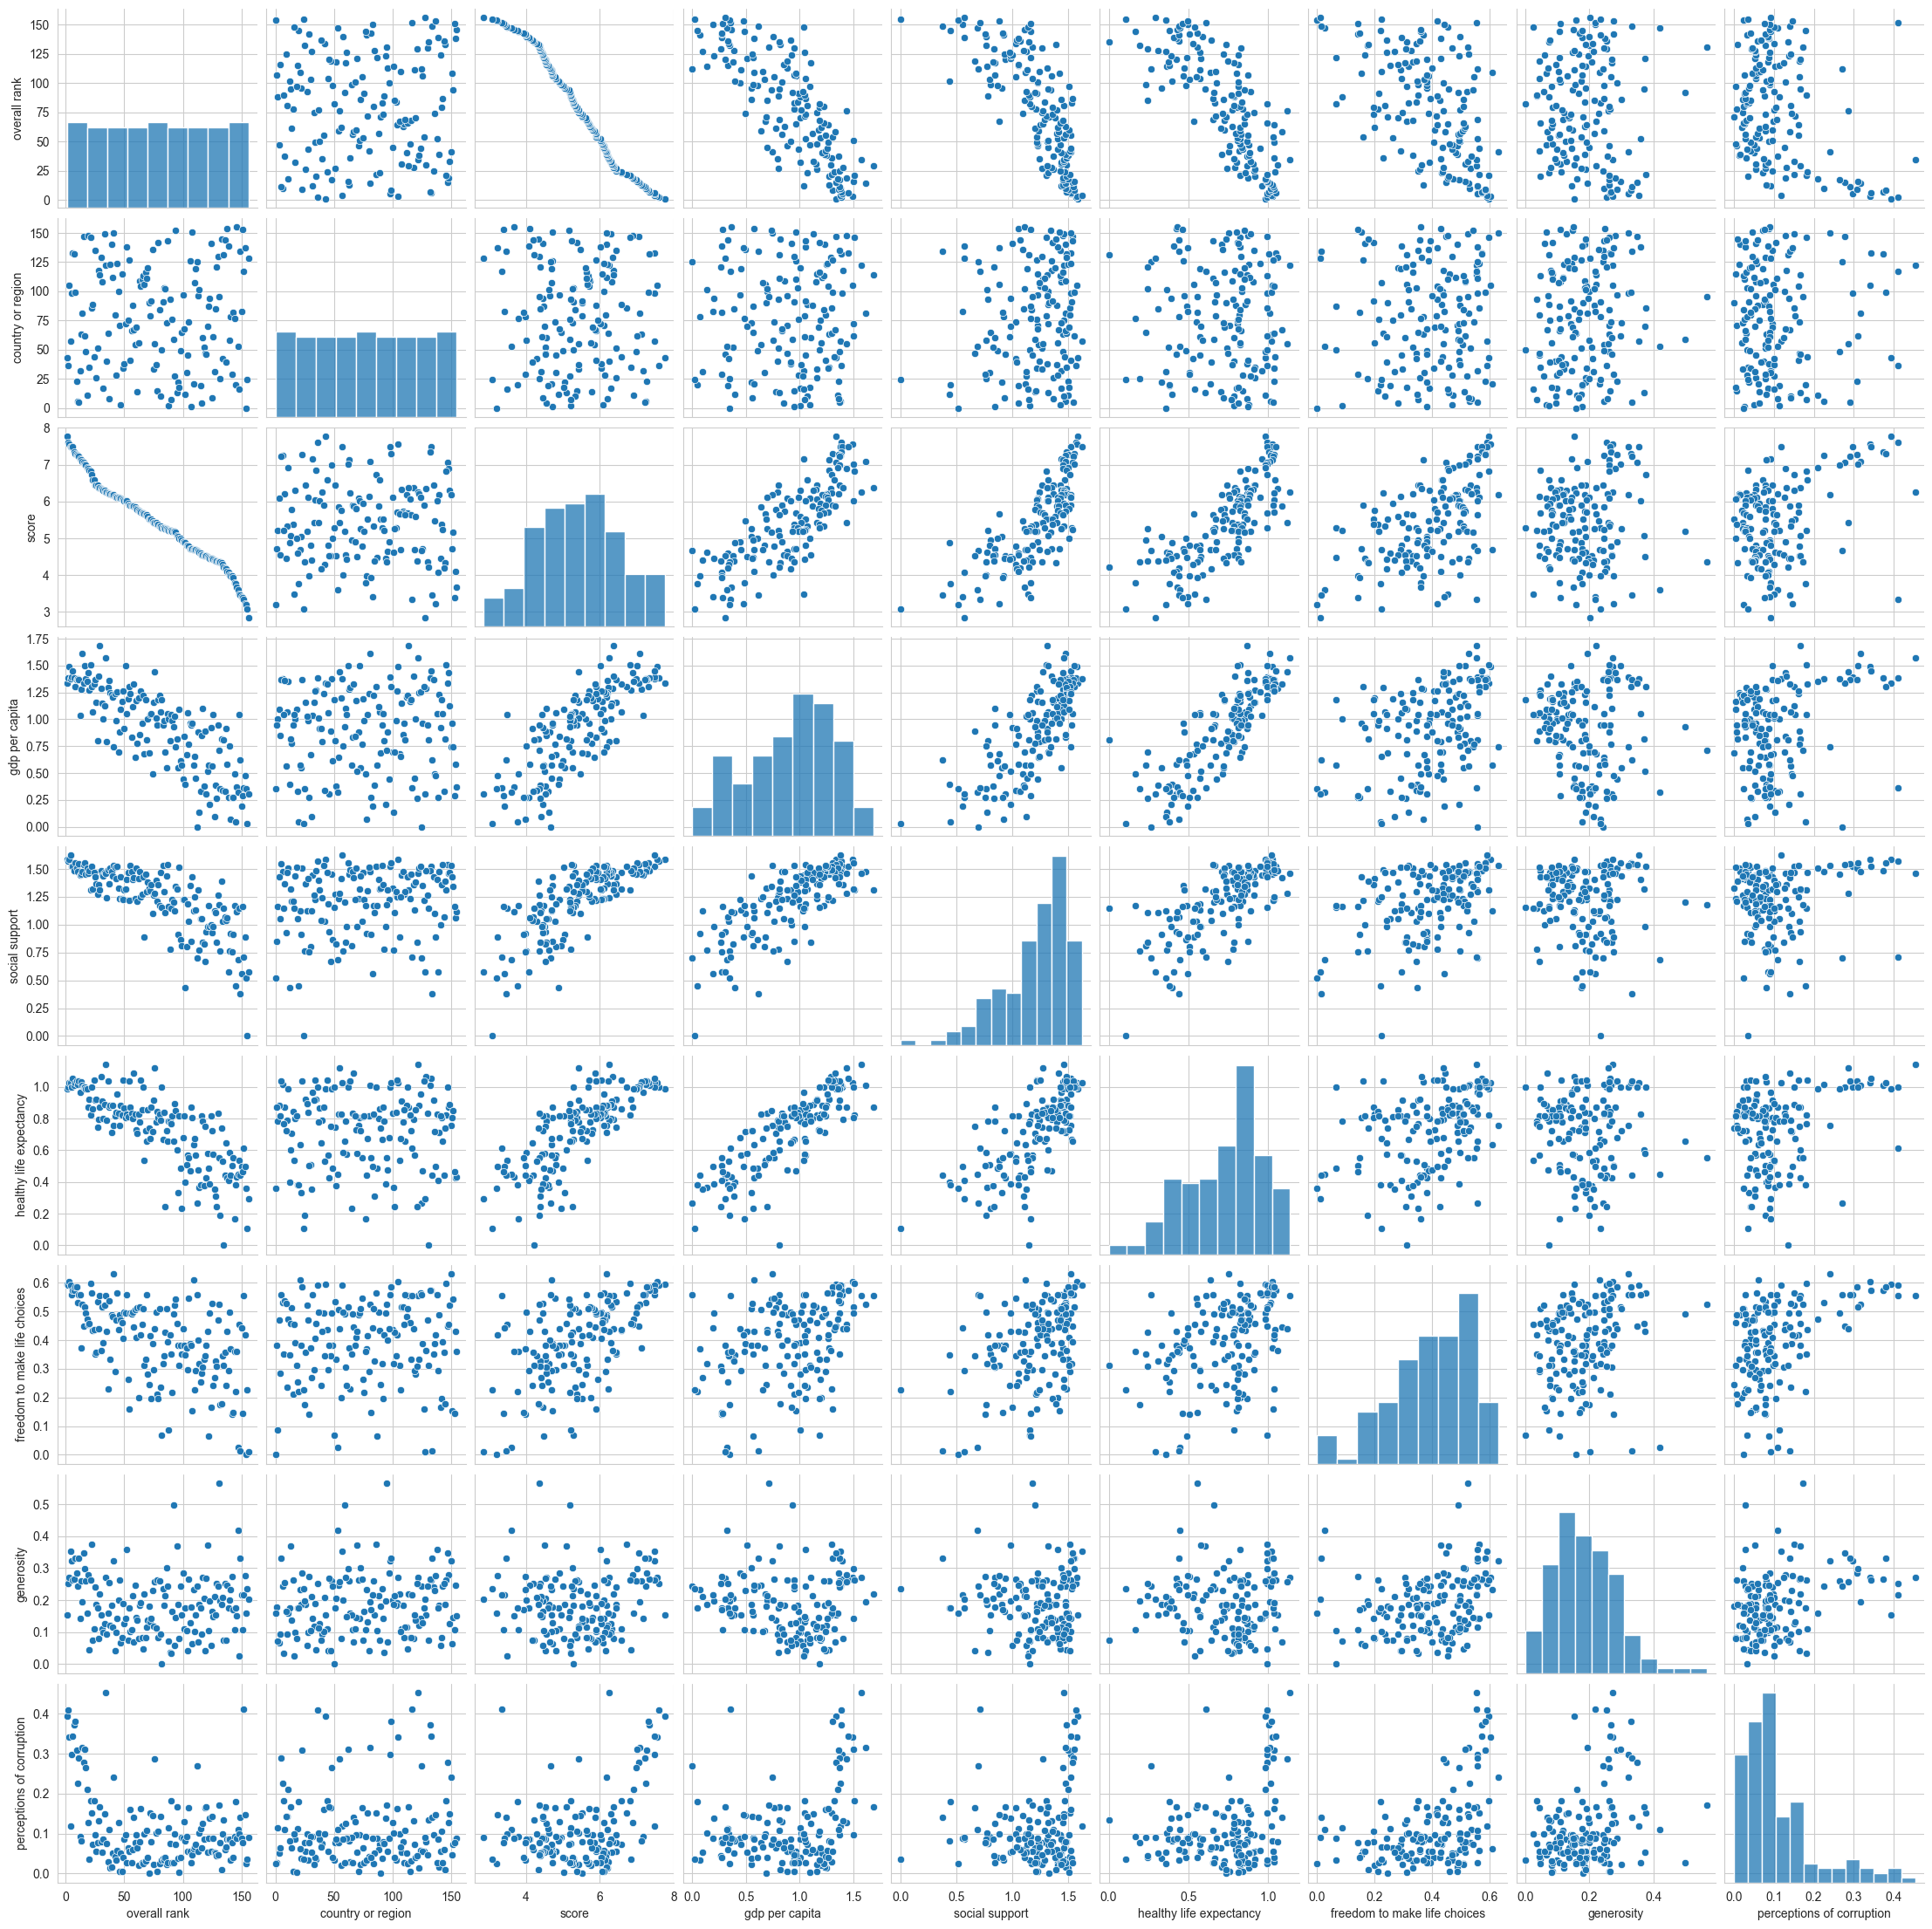

In [149]:
sns.pairplot(df)
# plt.savefig("pair_plot_jpg", dpi=300)

In [150]:
df.columns

Index(['overall rank', 'country or region', 'score', 'gdp per capita',
       'social support', 'healthy life expectancy',
       'freedom to make life choices', 'generosity',
       'perceptions of corruption'],
      dtype='object')

<Axes: >

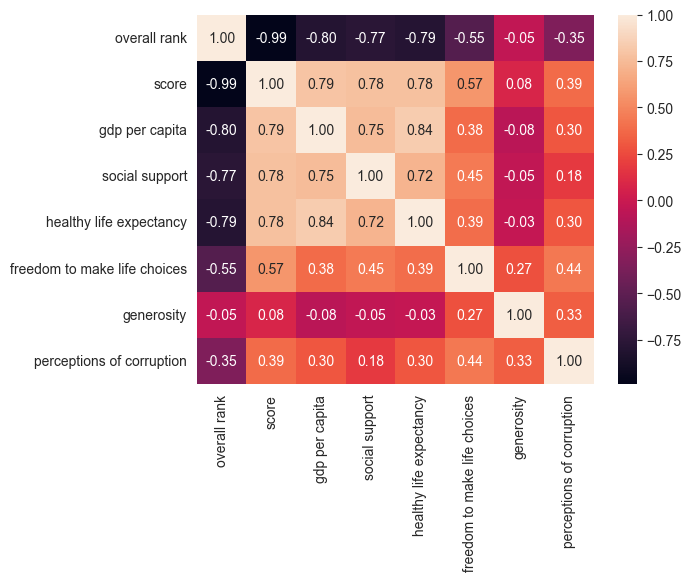

In [151]:
sns.heatmap(df.drop(columns=["country or region"]).corr(),annot=True, fmt="0.2f")

In [152]:
df.columns

Index(['overall rank', 'country or region', 'score', 'gdp per capita',
       'social support', 'healthy life expectancy',
       'freedom to make life choices', 'generosity',
       'perceptions of corruption'],
      dtype='object')

In [153]:
# plt.subplot(nrows, ncols, index)

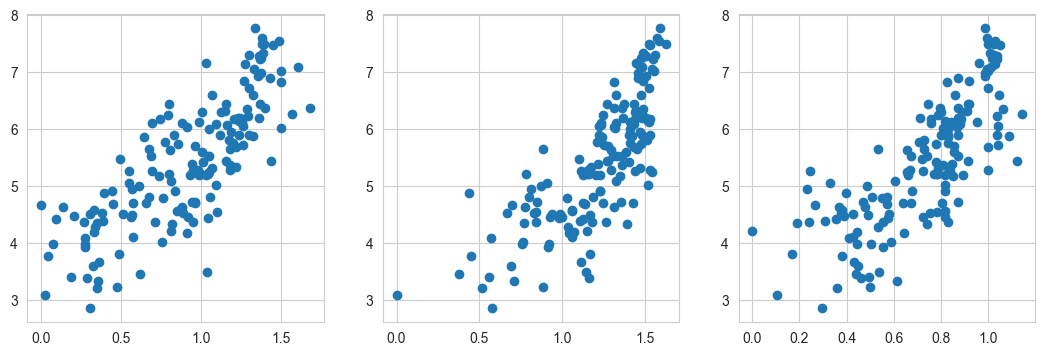

In [154]:
plt.figure(figsize=(13,4))
plt.subplot(131)
plt.scatter(df["gdp per capita"], df["score"])
plt.subplot(132)
plt.scatter(df["social support"], df["score"])
plt.subplot(133)
plt.scatter(df['healthy life expectancy'], df["score"])
plt.show()

In [155]:
df.corr(numeric_only=True)

,overall rank,country or region,score,gdp per capita,social support,healthy life expectancy,freedom to make life choices,generosity,perceptions of corruption
overall rank,1.000000,0.009578,-0.989096,-0.801947,-0.767465,-0.787411,-0.546606,-0.047993,-0.351959
country or region,0.009578,1.000000,-0.023039,0.021662,0.135603,-0.026412,0.041065,0.114529,0.029526
score,-0.989096,-0.023039,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
gdp per capita,-0.801947,0.021662,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
social support,-0.767465,0.135603,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
healthy life expectancy,-0.787411,-0.026412,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
freedom to make life choices,-0.546606,0.041065,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
generosity,-0.047993,0.114529,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
perceptions of corruption,-0.351959,0.029526,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


In [156]:
df['score'].mean(), df['score'].min(), df['score'].max()

(5.407096153846155, 2.853, 7.769)

## Findings from 2019 EDA